<a href="https://colab.research.google.com/github/GhulamMujtabaKhan2005/Supply-Chain-Analytics-portfolio/blob/main/00%20-%20Initial%20Working/testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

# Load the 'Procurement_Data' sheet, assuming headers are in the first row (index 0)
df = pd.read_excel('Chenab_Motors_Procurement_Practice_Dataset.xlsx', sheet_name='Procurement_Data', header=0)

print("Dataset loaded successfully from 'Procurement_Data' sheet. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully from 'Procurement_Data' sheet. Displaying the first 5 rows:


,PO Number,PO Line Item,Vendor ID,Vendor,Plant,Department,Cost Center,Requisitioner,Material Group,Quantity,...,Creation Date,GR Date,GR Value (PKR),Invoice Date,Invoice Amount (PKR),Paid Amount (PKR),Outstanding Invoice (PKR),Payment Terms,Currency,PO Status
0,PO-100307,2,V-1057,Al-Noor Fabric Exports,Lahore Plant,Quality Assurance,CC-3001,I. Chaudhry,MRO & Spares,3,...,2024-05-31 00:00:00,2024-06-17,7293.0,2024-06-18,7185.0,2910,4275,Net 60,PKR,Partially Invoiced
1,PO-101660,1,V-1010,Modern Fasteners Co.,Faisalabad Plant,Production,CC-1003,H. Malik,Engine & Powertrain Components,11,...,2024-07-23 00:00:00,2024-07-30,256257.0,2024-08-09,256526.0,63790,192736,Net 45,PKR,Partially Invoiced
2,PO-107059,1,V-1055,Wazir Ali Enterprises,Faisalabad Plant,IT,CC-5001,I. Chaudhry,Interior Components,3,...,2025-05-11 00:00:00,2025-05-16,9539.0,2025-05-23,9586.0,9586,0,Net 30,PKR,Closed
3,PO-102998,1,V-1027,Eco Weave Pakistan,Karachi Plant,Maintenance,CC-2001,N. Sheikh,Body Panels & Sheet Metal,7,...,2024-10-09 00:00:00,2024-10-23,115883.0,2024-10-27,116924.0,116924,0,Net 45,PKR,Closed
4,PO-106461,1,V-1032,Al-Rehan Fabric Mills,Lahore Plant,Administration,CC-6002,Z. Latif,Office Supplies & Stationery,1,...,2025-03-03 00:00:00,2025-03-07,523.0,2025-03-15,517.0,517,0,Net 30,PKR,Closed


## Data Cleaning and Preprocessing

Now, I'll perform some basic data cleaning. This includes checking for missing values and standardizing the 'Vendor' column, which is crucial for accurate aggregation.

In [ ]:
# Display info and check for missing values
print("DataFrame Info:")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

# Standardize the 'Vendor' column
df['Vendor'] = df['Vendor'].astype(str).str.strip().str.title()
print("\n'Vendor' column cleaned and standardized. Displaying unique vendors and their counts:")
display(df['Vendor'].value_counts().head())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   PO Number                  10050 non-null  object        
 1   PO Line Item               10050 non-null  int64         
 2   Vendor ID                  10050 non-null  object        
 3   Vendor                     9930 non-null   object        
 4   Plant                      10050 non-null  object        
 5   Department                 10050 non-null  object        
 6   Cost Center                9929 non-null   object        
 7   Requisitioner              10050 non-null  object        
 8   Material Group             9927 non-null   object        
 9   Quantity                   10050 non-null  int64         
 10  Unit Price (PKR)           10050 non-null  int64         
 11  PO Value (PKR)             10050 non-null  float64 

,count
Vendor,
Al-Amin Auto Components,1620
Karachi Steel Traders,905
Zaman Brothers Trading,603
Anwar Electric Works,522
Tcs Cargo Services,368


## Identify Top 5 Vendors by Volume and Purchases

Based on the column names, I will use 'Quantity' for 'Volume' and 'PO Value (PKR)' for 'Purchases'.

In [ ]:
# Define the columns for analysis
volume_column_name = 'Quantity'
purchase_column_name = 'PO Value (PKR)'

# Ensure these columns exist and are numeric
if volume_column_name not in df.columns:
    print(f"Error: '{volume_column_name}' column not found in DataFrame.")
if purchase_column_name not in df.columns:
    print(f"Error: '{purchase_column_name}' column not found in DataFrame.")

df[volume_column_name] = pd.to_numeric(df[volume_column_name], errors='coerce')
df[purchase_column_name] = pd.to_numeric(df[purchase_column_name], errors='coerce')

# Drop rows where 'Quantity' or 'PO Value (PKR)' are NaN after conversion
df_cleaned = df.dropna(subset=[volume_column_name, purchase_column_name])

# Calculate Top 5 Vendors by Volume
supplier_volume = df_cleaned.groupby('Vendor')[volume_column_name].sum().sort_values(ascending=False)
total_volume = supplier_volume.sum()

if total_volume > 0:
    top_5_volume = (supplier_volume / total_volume * 100).reset_index(name='Percentage_Volume')
    top_5_volume = top_5_volume.head(5)
    print("\nTop 5 Vendors by Volume Percentage:")
    display(top_5_volume)
else:
    print("Total volume is zero, cannot calculate volume percentages.")

# Calculate Top 5 Vendors by Purchases
supplier_purchases = df_cleaned.groupby('Vendor')[purchase_column_name].sum().sort_values(ascending=False)
total_purchases = supplier_purchases.sum()

if total_purchases > 0:
    top_5_purchases = (supplier_purchases / total_purchases * 100).reset_index(name='Percentage_Purchases')
    top_5_purchases = top_5_purchases.head(5)
    print("\nTop 5 Vendors by Purchases Percentage:")
    display(top_5_purchases)
else:
    print("Total purchases are zero, cannot calculate purchase percentages.")


Top 5 Vendors by Volume Percentage:


,Vendor,Percentage_Volume
0,Al-Amin Auto Components,16.442248
1,Karachi Steel Traders,8.660894
2,Zaman Brothers Trading,6.471868
3,Anwar Electric Works,5.960315
4,Tcs Cargo Services,3.598253



Top 5 Vendors by Purchases Percentage:


,Vendor,Percentage_Purchases
0,Al-Amin Auto Components,16.575317
1,Karachi Steel Traders,8.146245
2,Zaman Brothers Trading,5.835024
3,Anwar Electric Works,5.119296
4,Tcs Cargo Services,4.398709


## Visualization of Top 5 Vendors

Finally, let's visualize the top 5 vendors based on both volume and purchases to better understand their contributions.

/tmp/ipykernel_5894/1065025050.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vendor', y='Percentage_Volume', data=top_5_volume, palette='Blues_d')


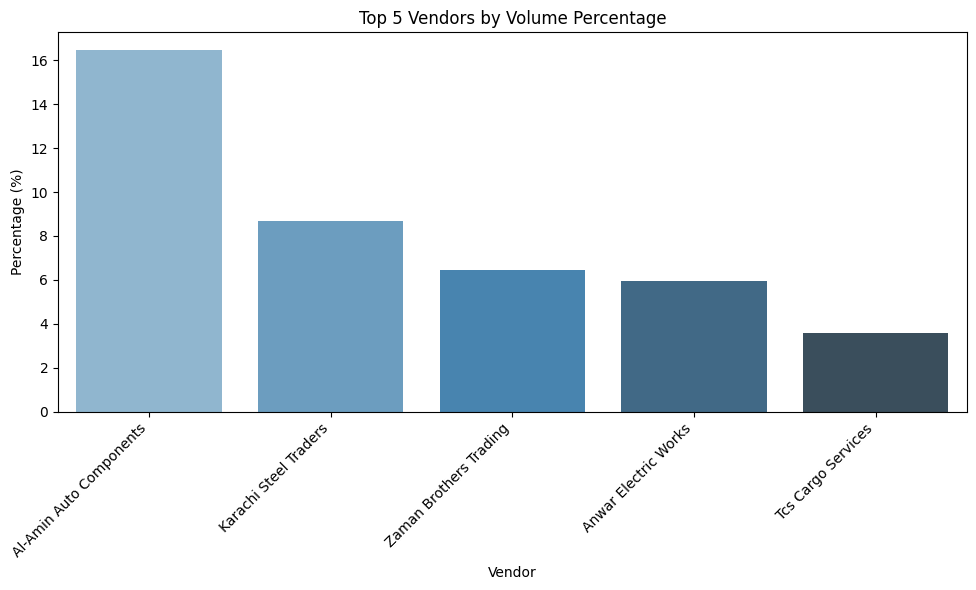

/tmp/ipykernel_5894/1065025050.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vendor', y='Percentage_Purchases', data=top_5_purchases, palette='Greens_d')


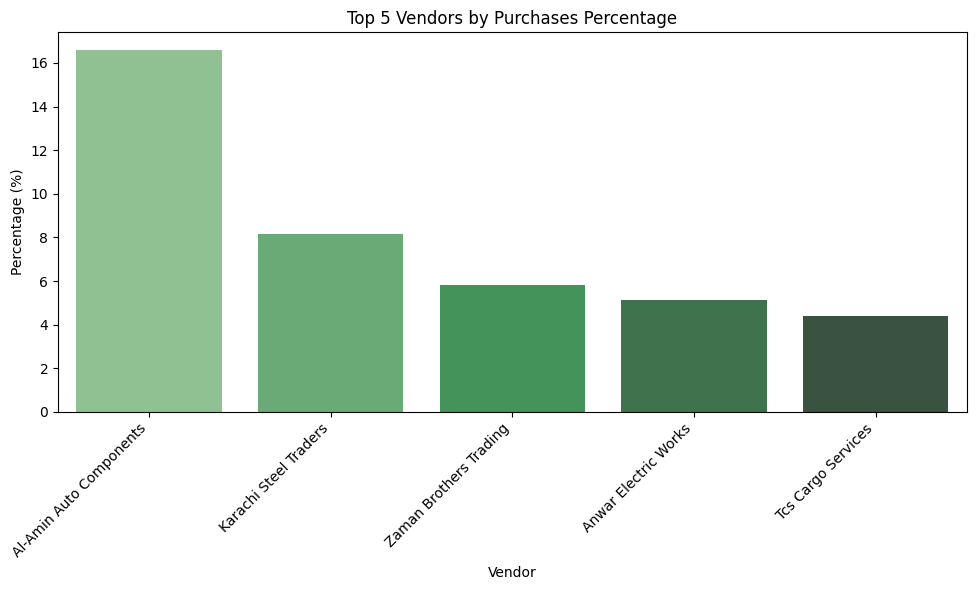

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for Top 5 by Volume
if 'top_5_volume' in locals() and not top_5_volume.empty:
    fig_vol = plt.figure(figsize=(10, 6))
    sns.barplot(x='Vendor', y='Percentage_Volume', data=top_5_volume, palette='Blues_d')
    plt.title('Top 5 Vendors by Volume Percentage')
    plt.xlabel('Vendor')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Top 5 vendors by volume data not available for visualization.")

# Plot for Top 5 by Purchases
if 'top_5_purchases' in locals() and not top_5_purchases.empty:
    fig_pur = plt.figure(figsize=(10, 6))
    sns.barplot(x='Vendor', y='Percentage_Purchases', data=top_5_purchases, palette='Greens_d')
    plt.title('Top 5 Vendors by Purchases Percentage')
    plt.xlabel('Vendor')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Top 5 vendors by purchases data not available for visualization.")

## Key Procurement Metrics

Let's calculate some overall procurement metrics from the dataset.

In [ ]:
# Total PO Spend
total_po_spend = df['PO Value (PKR)'].sum()
print(f"Total PO Spend: {total_po_spend:,.2f} PKR")

# Total number of unique POs
total_num_pos = df['PO Number'].nunique()
print(f"Total Number of Purchase Orders: {total_num_pos:,}")

# Total number of unique Vendors
total_num_vendors = df['Vendor'].nunique()
print(f"Total Number of Vendors: {total_num_vendors:,}")

# Average PO Value (average of 'PO Value (PKR)' per unique 'PO Number')
# First, group by 'PO Number' and sum 'PO Value (PKR)' for each PO, then average those sums.
po_value_per_po = df.groupby('PO Number')['PO Value (PKR)'].sum()
average_po_value = po_value_per_po.mean()
print(f"Average Purchase Order Value: {average_po_value:,.2f} PKR")

# Average Line Item Value (average of 'PO Value (PKR)' per 'PO Line Item')
# Note: This assumes 'PO Line Item' combined with 'PO Number' identifies a unique line item.
# If 'PO Line Item' is unique within a PO, we can just average 'PO Value (PKR)'.
# For robustness, we'll consider each row as a distinct line item and take the average of 'PO Value (PKR)'.
average_line_item_value = df['PO Value (PKR)'].mean()
print(f"Average Line Item Value (from PO Value): {average_line_item_value:,.2f} PKR")

Total PO Spend: 614,670,044.11 PKR
Total Number of Purchase Orders: 7,406
Total Number of Vendors: 61
Average Purchase Order Value: 82,996.23 PKR
Average Line Item Value (from PO Value): 61,161.20 PKR


In [ ]:
min_gr_date = df['GR Date'].min()
max_gr_date = df['GR Date'].max()
min_invoice_date = df['Invoice Date'].min()
max_invoice_date = df['Invoice Date'].max()

start_date = min(min_gr_date, min_invoice_date)
end_date = max(max_gr_date, max_invoice_date)

print(f"The data spans from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}.")

The data spans from 2024-03-04 to 2025-10-04.


In [ ]:
# Group by Vendor and count unique PO Numbers
po_counts_per_vendor = df.groupby('Vendor')['PO Number'].nunique()

# Filter for vendors with exactly one PO
vendors_with_one_po = po_counts_per_vendor[po_counts_per_vendor == 1]

print("Suppliers with only one Purchase Order:")
display(vendors_with_one_po)

Suppliers with only one Purchase Order:


,PO Number
Vendor,


In [ ]:
# Calculate total PO Value per vendor
vendor_spend = df.groupby('Vendor')['PO Value (PKR)'].sum().sort_values(ascending=False)

# Calculate total spend
total_spend = vendor_spend.sum()

# Calculate cumulative spend and cumulative percentage
pareto_analysis = pd.DataFrame({
    'Total Spend (PKR)': vendor_spend,
    'Cumulative Spend (PKR)': vendor_spend.cumsum(),
    'Cumulative Percentage (%)': (vendor_spend.cumsum() / total_spend * 100)
})

# Identify vendors contributing to 80% of total spend
pareto_80_percent_vendors = pareto_analysis[pareto_analysis['Cumulative Percentage (%)'] <= 80]

print("Pareto Analysis of Vendors by PO Value:")
display(pareto_analysis)

print("\nVendors contributing to the first 80% of total spend:")
display(pareto_80_percent_vendors)

Pareto Analysis of Vendors by PO Value:


,Total Spend (PKR),Cumulative Spend (PKR),Cumulative Percentage (%)
Vendor,,,
Al-Amin Auto Components,1.018835e+08,1.018835e+08,16.575317
Karachi Steel Traders,5.007253e+07,1.519560e+08,24.721562
Zaman Brothers Trading,3.586614e+07,1.878222e+08,30.556586
Anwar Electric Works,3.146678e+07,2.192890e+08,35.675882
Tcs Cargo Services,2.703754e+07,2.463265e+08,40.074590
...,...,...,...
City Hardware House,2.741781e+06,6.052520e+08,98.467795
General Tyre Pakistan,2.476222e+06,6.077283e+08,98.870649
Greencharge Industries,2.409113e+06,6.101374e+08,99.262585



Vendors contributing to the first 80% of total spend:


,Total Spend (PKR),Cumulative Spend (PKR),Cumulative Percentage (%)
Vendor,,,
Al-Amin Auto Components,1.018835e+08,1.018835e+08,16.575317
Karachi Steel Traders,5.007253e+07,1.519560e+08,24.721562
Zaman Brothers Trading,3.586614e+07,1.878222e+08,30.556586
Anwar Electric Works,3.146678e+07,2.192890e+08,35.675882
Tcs Cargo Services,2.703754e+07,2.463265e+08,40.074590
Gulistan Logistics,1.972002e+07,2.660465e+08,43.282819
Speedline Logistics,1.750654e+07,2.835531e+08,46.130939
Sindh Spinners Co.,1.655498e+07,3.001080e+08,48.824251
United Rubber Industries,1.587658e+07,3.159846e+08,51.407194
